In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
import importlib

In [2]:
# Get the path of the notebook file
notebook_path = os.getcwd()

# Directory containing the notebook file
notebook_directory = os.path.dirname(notebook_path)
notebook_directory

'/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate'

In [3]:
sys.path.append(os.path.join(notebook_directory, 'src'))
import cubical_pers_and_filt_visual, globe_visualization, feature_tracking

importlib.reload(cubical_pers_and_filt_visual)
importlib.reload(globe_visualization)
importlib.reload(feature_tracking)

<module 'feature_tracking' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/feature_tracking.py'>

# Visulalization

In [4]:
# Load specific year and day
df = feature_tracking.load_all_representative_data_to_df(years=1948, days=1,notebook_dir=notebook_directory)
df

,year,day,data_type,feature_index,birth,death,persistence,representative,death_simplex_vertices
0,1948,1,sub,61,-54.341457,1685.783813,1740.125271,"[[[64, 74], [65, 74]], [[65, 74], [66, 74]], [...","[[105, 123], [106, 123], [105, 124], [106, 124]]"
1,1948,1,sub,60,207.378220,1677.995850,1470.617630,"[[[53, 7], [53, 8]], [[52, 8], [53, 8]], [[145...","[[83, 18], [84, 18], [83, 19], [84, 19]]"
2,1948,1,sub,59,139.274673,1246.956787,1107.682114,"[[[88, 109], [88, 110]], [[88, 110], [88, 111]...","[[64, 108], [65, 108], [64, 109], [65, 109]]"
3,1948,1,sub,58,-33.940052,504.925354,538.865406,"[[[111, 85], [112, 85]], [[112, 85], [113, 85]...","[[118, 72], [119, 72], [118, 73], [119, 73]]"
4,1948,1,sub,57,108.889824,624.874939,515.985115,"[[[46, 60], [46, 61]], [[46, 61], [46, 62]], [...","[[57, 56], [58, 56], [57, 57], [58, 57]]"
...,...,...,...,...,...,...,...,...,...
134,1948,1,sup,4,151.073303,151.747147,0.673843,"[[[74, 74], [75, 74]], [[75, 74], [76, 74]], [...","[[75, 72], [76, 72], [75, 73], [76, 73]]"
135,1948,1,sup,3,294.944153,295.232025,0.287872,"[[[134, 142], [135, 142]], [[135, 142], [136, ...","[[135, 140], [136, 140], [135, 141], [136, 141]]"
136,1948,1,sup,2,385.278778,385.528870,0.250092,"[[[102, 153], [102, 154]], [[102, 154], [103, ...","[[102, 152], [103, 152], [102, 153], [103, 153]]"
137,1948,1,sup,1,638.267822,638.491516,0.223694,"[[[26, 103], [27, 103]], [[27, 103], [28, 103]...","[[25, 101], [26, 101], [25, 102], [26, 102]]"


# Tracking

## Sublevel

In [5]:
results_sub = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948,
    end_year=2023,
    data_type='sub',
    notebook_dir=notebook_directory,
    persistence_threshold=1000,
    alpha=0,
    beta=1,
    distance_threshold=1000,
    matrix_size=172
)

LOADING CACHED RESULTS
Loading cached results from: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sub_1948-2023_pers1000_a0_b1_dist1000_size172.pkl
Cache created: 2026-04-03T09:21:10.295334
Total trajectories: 38221
Cached results loaded successfully!


In [6]:
summary_df = feature_tracking.get_trajectory_summary(results_sub)

Created summary DataFrame with 38221 trajectories


In [7]:
feature_tracking.get_overall_summary_stats(results_sub,summary_df)

=== TRAJECTORY ANALYSIS SUMMARY ===
Data type: sub
Start year: 1948
End year: 2023
Persistence threshold: 1000
Alpha (topological weight): 0
Beta (spatial weight): 1
Distance threshold: 1000
Matrix size: 172

=== TRAJECTORY LENGTH STATISTICS ===
Total trajectories: 38221
Mean length: 1.47 days
Median length: 1.00 days
Max length: 17 days
Min length: 1 days
Std length: 1.01 days

=== TRAJECTORY LIFESPAN STATISTICS ===
Mean lifespan: 0.47 days
Median lifespan: 0.00 days
Max lifespan: 16 days

=== PERSISTENCE STATISTICS ===
Mean persistence: 1659.0914
Max persistence (across all): 7280.9768
Min persistence (across all): 1000.0208
Std of mean persistence: 719.5630

=== BIRTH-DEATH STATISTICS ===
Mean birth value: 158.4457
Mean death value: 1817.5371

=== SPATIAL MOVEMENT STATISTICS ===
Mean total movement: 225.58 km
Max total movement: 6589.88 km
Mean avg movement per day: 138.92 km/day
Max single-day movement: 999.85 km

=== TRAJECTORY DURATION DISTRIBUTION ===
1 day: 27639 trajectories (

{'trajectory_count': 38221,
 'mean_length': np.float64(1.4679888019675047),
 'mean_lifespan': np.float64(0.4685905653959865),
 'mean_persistence': np.float64(1659.091383058559),
 'duration_distribution': trajectory_length
 1 day         27639
 2-4 days       9805
 5-9 days        731
 10-19 days       46
 20-49 days        0
 50-99 days        0
 100+ days         0
 Name: count, dtype: int64,
 'top_trajectories_by_length':                  trajectory_id  trajectory_length  trajectory_lifespan  \
 trajectory_rank                                                          
 1                        29243                 17                   16   
 2                          219                 16                   15   
 3                        26825                 16                   15   
 4                        28445                 16                   15   
 5                         7223                 15                   14   
 6                         4646                 

In [8]:
recommendations = feature_tracking.get_trajectory_recommendations(results_sub, summary_df, notebook_directory)

=== TRAJECTORY RECOMMENDATIONS ===
LONGEST:
  Trajectory ID: 29243 (Rank 1)
  Reason: Longest duration trajectory
  Stats: 17 days, 16 day lifespan
  Plot command: plot_trajectory_slider(results, 29243, notebook_dir)

MOST_PERSISTENT:
  Trajectory ID: 22710 (Rank 7936)
  Reason: Highest average persistence
  Stats: Persistence: 7134.9429, 2 days
  Plot command: plot_trajectory_slider(results, 22710, notebook_dir)

MOST_MOBILE:
  Trajectory ID: 29243 (Rank 1)
  Reason: Greatest spatial movement
  Stats: Movement: 6589.88 km, 17 days
  Plot command: plot_trajectory_slider(results, 29243, notebook_dir)



## Superlevel

In [9]:
results_sup = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948,
    end_year=2023,
    data_type='sup',
    notebook_dir=notebook_directory,
    persistence_threshold=1000,
    alpha=0,
    beta=1,
    distance_threshold=1000,
    matrix_size=172
)

LOADING CACHED RESULTS
Loading cached results from: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sup_1948-2023_pers1000_a0_b1_dist1000_size172.pkl
Cache created: 2026-04-03T09:29:49.631280
Total trajectories: 94169
Cached results loaded successfully!


In [10]:
summary_df = feature_tracking.get_trajectory_summary(results_sup)
summary_df

Created summary DataFrame with 94169 trajectories


,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
1,19893,11,10,1964-05-01,1964-05-11,3089.638089,4769.605591,1393.049805,977.432269,-14.243203,...,34.0,59.0,34.0,6010.069552,601.006955,997.104131,"[1964-05-01, 1964-05-02, 1964-05-03, 1964-05-0...","[(-467.078857421875, 3134.28369140625), (-786....","[3601.362548828125, 4769.6055908203125, 3571.3...","[(72.0, 34.0), (62.0, 35.0), (59.0, 34.0), (66..."
2,19620,11,10,1964-02-17,1964-02-27,4173.328299,5744.057587,3129.170761,663.503285,-46.502327,...,45.0,66.0,36.0,6511.004334,651.100433,944.486834,"[1964-02-17, 1964-02-18, 1964-02-19, 1964-02-2...","[(-285.9198913574219, 3801.493408203125), (-29...","[4087.413299560547, 4332.885406494141, 3568.20...","[(98.0, 45.0), (93.0, 43.0), (86.0, 45.0), (78..."
3,30089,9,8,1972-07-15,1972-07-23,2044.078287,2353.897087,1383.307281,277.151388,-33.376098,...,106.0,79.0,109.0,1519.172880,189.896610,260.489729,"[1972-07-15, 1972-07-16, 1972-07-17, 1972-07-1...","[(360.8429870605469, 1744.1502685546875), (-57...","[1383.3072814941406, 1871.6809425354004, 1965....","[(82.0, 106.0), (82.0, 107.0), (81.0, 109.0), ..."
4,38299,9,8,1979-01-29,1979-02-06,5559.340529,6440.488525,4934.025391,409.424157,-1097.446513,...,49.0,101.0,40.0,4262.936493,532.867062,941.754830,"[1979-01-29, 1979-01-30, 1979-01-31, 1979-02-0...","[(-1087.66943359375, 4319.7607421875), (-1242....","[5407.43017578125, 5593.8699951171875, 5400.13...","[(99.0, 49.0), (99.0, 47.0), (93.0, 47.0), (91..."
5,19887,9,8,1964-05-01,1964-05-09,2100.031936,2553.707703,1702.031464,312.524298,349.339917,...,70.0,116.0,46.0,4384.242942,548.030368,956.932262,"[1964-05-01, 1964-05-02, 1964-05-03, 1964-05-0...","[(301.7712707519531, 2003.802734375), (420.729...","[1702.0314636230469, 1705.2449035644531, 2390....","[(125.0, 70.0), (127.0, 69.0), (127.0, 67.0), ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94165,59639,1,0,1996-06-16,1996-06-16,1231.640522,1231.640522,1231.640522,0.000000,7.778789,...,119.0,75.0,119.0,0.000000,0.000000,0.000000,[1996-06-16],"[(7.778789043426514, 1239.4193115234375)]",[1231.640522480011],"[(75.0, 119.0)]"
94166,59640,1,0,1996-06-16,1996-06-16,1296.891739,1296.891739,1296.891739,0.000000,-91.520035,...,90.0,69.0,90.0,0.000000,0.000000,0.000000,[1996-06-16],"[(-91.52003479003906, 1205.3717041015625)]",[1296.8917388916016],"[(69.0, 90.0)]"
94167,59641,1,0,1996-06-16,1996-06-16,1326.555847,1326.555847,1326.555847,0.000000,-247.232971,...,76.0,23.0,76.0,0.000000,0.000000,0.000000,[1996-06-16],"[(-247.23297119140625, 1079.3228759765625)]",[1326.5558471679688],"[(23.0, 76.0)]"


In [11]:
feature_tracking.get_overall_summary_stats(results_sup,summary_df)

=== TRAJECTORY ANALYSIS SUMMARY ===
Data type: sup
Start year: 1948
End year: 2023
Persistence threshold: 1000
Alpha (topological weight): 0
Beta (spatial weight): 1
Distance threshold: 1000
Matrix size: 172

=== TRAJECTORY LENGTH STATISTICS ===
Total trajectories: 94169
Mean length: 1.25 days
Median length: 1.00 days
Max length: 11 days
Min length: 1 days
Std length: 0.61 days

=== TRAJECTORY LIFESPAN STATISTICS ===
Mean lifespan: 0.25 days
Median lifespan: 0.00 days
Max lifespan: 10 days

=== PERSISTENCE STATISTICS ===
Mean persistence: 1832.3022
Max persistence (across all): 8748.9951
Min persistence (across all): 1000.0054
Std of mean persistence: 810.0163

=== BIRTH-DEATH STATISTICS ===
Mean birth value: 193.4591
Mean death value: 2025.7613

=== SPATIAL MOVEMENT STATISTICS ===
Mean total movement: 132.42 km
Max total movement: 6511.00 km
Mean avg movement per day: 99.73 km/day
Max single-day movement: 999.88 km

=== TRAJECTORY DURATION DISTRIBUTION ===
1 day: 76912 trajectories (8

{'trajectory_count': 94169,
 'mean_length': np.float64(1.2470876827830815),
 'mean_lifespan': np.float64(0.2473106861068929),
 'mean_persistence': np.float64(1832.302220199725),
 'duration_distribution': trajectory_length
 1 day         76912
 2-4 days      16922
 5-9 days        333
 10-19 days        2
 20-49 days        0
 50-99 days        0
 100+ days         0
 Name: count, dtype: int64,
 'top_trajectories_by_length':                  trajectory_id  trajectory_length  trajectory_lifespan  \
 trajectory_rank                                                          
 1                        19893                 11                   10   
 2                        19620                 11                   10   
 3                        30089                  9                    8   
 4                        38299                  9                    8   
 5                        19887                  9                    8   
 6                        54843                 

In [12]:
recommendations = feature_tracking.get_trajectory_recommendations(results_sup, summary_df, notebook_directory)

=== TRAJECTORY RECOMMENDATIONS ===
LONGEST:
  Trajectory ID: 19893 (Rank 1)
  Reason: Longest duration trajectory
  Stats: 11 days, 10 day lifespan
  Plot command: plot_trajectory_slider(results, 19893, notebook_dir)

MOST_PERSISTENT:
  Trajectory ID: 38433 (Rank 27765)
  Reason: Highest average persistence
  Stats: Persistence: 7621.4299, 1 days
  Plot command: plot_trajectory_slider(results, 38433, notebook_dir)

MOST_MOBILE:
  Trajectory ID: 19620 (Rank 2)
  Reason: Greatest spatial movement
  Stats: Movement: 6511.00 km, 11 days
  Plot command: plot_trajectory_slider(results, 19620, notebook_dir)



# Summary for paper

## Reviewer Check: Mean Area of Tracked Cyclones vs Anticyclones

Reviewer comment on Figure 11: *"The large difference in frequency between cyclones and anticyclones could be due to cyclones being broader in scale. The authors should check this by comparing the average areas occupied by the identified cyclones and anticyclones."*

For each snapshot of each tracked trajectory (year, day, feature_index), we load the representative 1-cycle from the JSON file and compute its geographic area. JSON files are loaded once per (year, day) pair. Results are cached to `area_sup_tracked.pkl` / `area_sub_tracked.pkl`.

In [13]:
import json
import pickle
from tqdm import tqdm

def get_trajectory_snapshot_areas(results, data_type, notebook_dir, cache_path=None):
    """
    For every (year, day, feature_index) snapshot in the tracked trajectories,
    load the representative 1-cycle from the JSON file and compute its area.
    Each JSON file is loaded only once per (year, day) pair.

    Returns a DataFrame with columns:
        year, day, date, feature_index, persistence, area_km2, month
    """
    if cache_path and os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            print(f"Loaded cached snapshot areas from {cache_path}")
            return pickle.load(f)

    records = []
    for traj in results['trajectories']:
        for snap in traj:
            records.append({
                'year':          snap['year'],
                'day':           snap['day'],
                'feature_index': int(snap['feature_index']),
                'date':          snap['date'],
                'persistence':   snap['persistence'],
            })

    snap_df = pd.DataFrame(records)

    base_folder = os.path.join(notebook_dir, 'data', 'processed_data', 'representative_data')
    area_map = {}

    for (year, day), group in tqdm(snap_df.groupby(['year', 'day']),
                                   desc=f'Computing areas for tracked {data_type} features'):
        filepath = os.path.join(base_folder, str(year),
                                f'slp_{data_type}_{year}_day_{day}.json')
        if not os.path.exists(filepath):
            continue
        with open(filepath, 'r') as f:
            data = json.load(f)
        reps = data.get('list_data', [])
        for fi in group['feature_index'].unique():
            if fi < len(reps):
                area_map[(year, day, fi)] = feature_tracking.compute_representative_area_km2(reps[fi])

    snap_df['area_km2'] = snap_df.apply(
        lambda r: area_map.get((r['year'], r['day'], r['feature_index']), np.nan), axis=1
    )
    snap_df['date']  = pd.to_datetime(snap_df['date'])
    snap_df['month'] = snap_df['date'].dt.month

    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        with open(cache_path, 'wb') as f:
            pickle.dump(snap_df, f)
        print(f"Saved to {cache_path}")

    return snap_df


area_cache_dir = os.path.join(notebook_directory, 'data', 'processed_data', 'area_data')

snap_sup = get_trajectory_snapshot_areas(
    results_sup, 'sup', notebook_directory,
    cache_path=os.path.join(area_cache_dir, 'area_sup_tracked.pkl')
)

snap_sub = get_trajectory_snapshot_areas(
    results_sub, 'sub', notebook_directory,
    cache_path=os.path.join(area_cache_dir, 'area_sub_tracked.pkl')
)

print(f"\nTotal snapshots — Cyclones (sup): {len(snap_sup):,}  |  Anticyclones (sub): {len(snap_sub):,}")

Loaded cached snapshot areas from /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/area_data/area_sup_tracked.pkl
Loaded cached snapshot areas from /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/area_data/area_sub_tracked.pkl

Total snapshots — Cyclones (sup): 117,437  |  Anticyclones (sub): 56,108


Created summary DataFrame with 94169 trajectories
Created summary DataFrame with 38221 trajectories


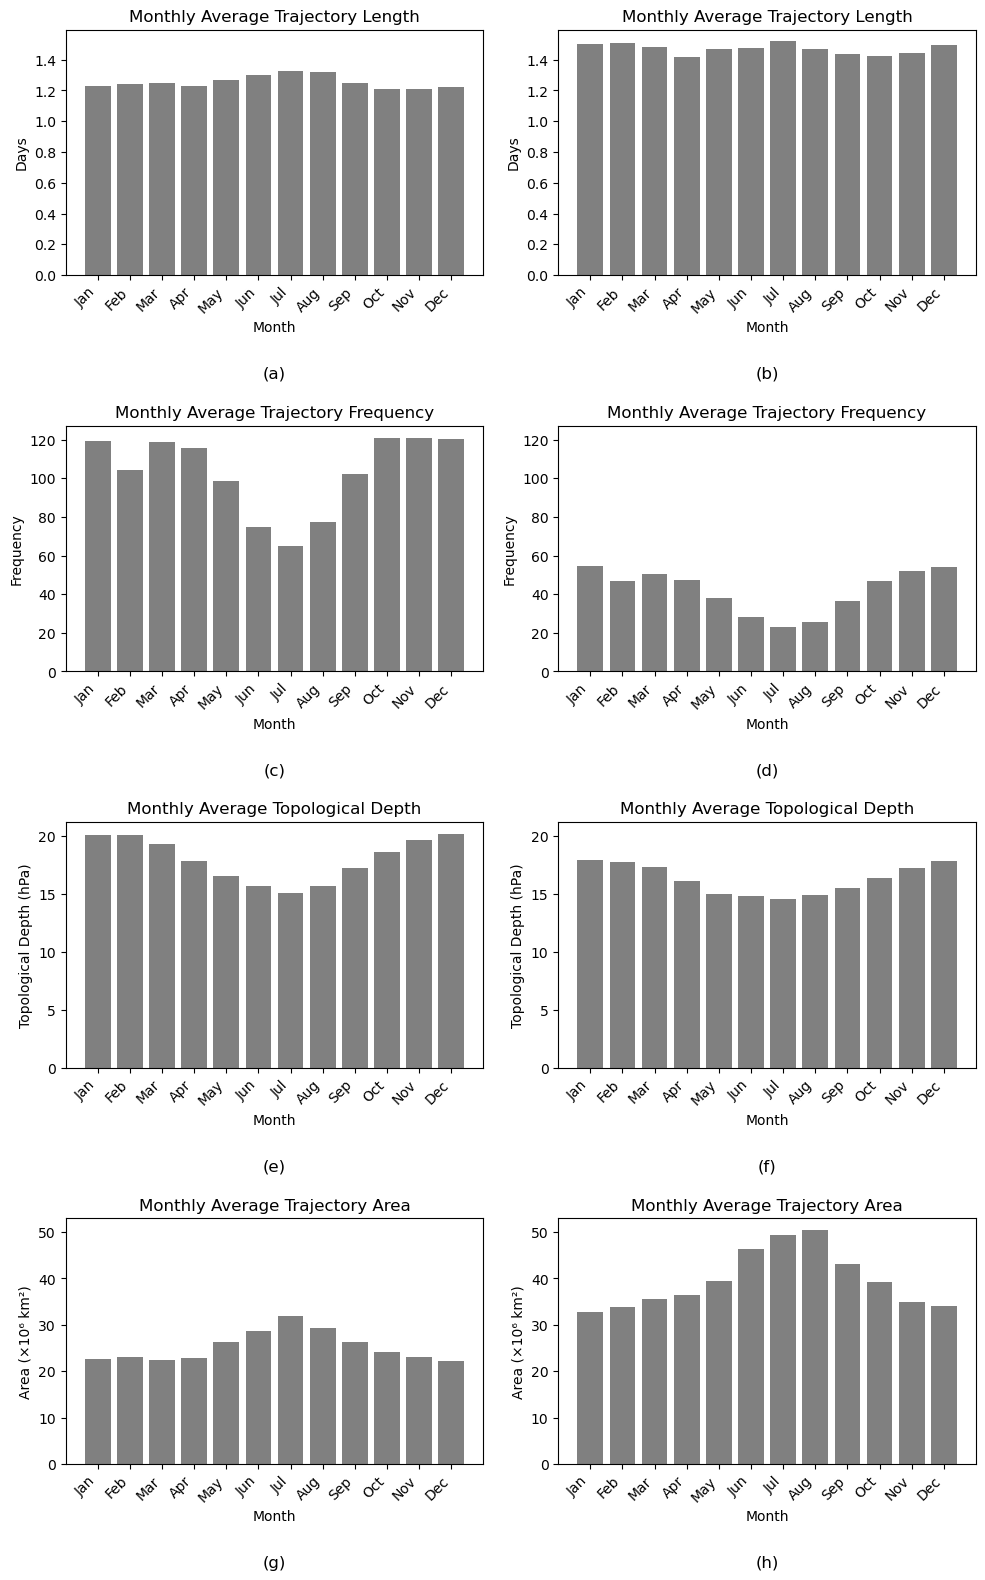

Saved trajectory_monthly_summaries.png


In [14]:
import pickle

# Figure 11: Monthly summaries — sup (cyclones, left) and sub (anticyclones, right)
summary_df_sup = feature_tracking.get_trajectory_summary(results_sup)
summary_df_sub = feature_tracking.get_trajectory_summary(results_sub)

def compute_monthly_stats(summary_df):
    df = summary_df.copy()
    df['start_date'] = pd.to_datetime(df['start_date'])
    df['month'] = df['start_date'].dt.month
    df['year']  = df['start_date'].dt.year

    monthly_length = df.groupby('month')['trajectory_length'].mean()
    monthly_freq = (
        df.groupby(['year', 'month']).size()
          .reset_index(name='count')
          .groupby('month')['count'].mean()
    )
    monthly_persistence = df.groupby('month')['mean_persistence'].mean() / 100
    return monthly_length, monthly_freq, monthly_persistence

def compute_area_monthly_stats(results, snap_area_df):
    """
    Per-trajectory mean area grouped by trajectory start month.
    Step 1: map each snapshot (year, day, feature_index) -> (trajectory_id, start_month).
    Step 2: compute mean area per trajectory.
    Step 3: average those per-trajectory means by start_month.
    Consistent with how length, frequency, and persistence are computed.
    """
    snap_to_traj = {}
    for traj_idx, traj in enumerate(results['trajectories']):
        start_month = pd.to_datetime(traj[0]['date']).month
        for snap in traj:
            key = (snap['year'], snap['day'], int(snap['feature_index']))
            snap_to_traj[key] = (traj_idx, start_month)

    df = snap_area_df.copy()
    mapped = df.apply(
        lambda r: snap_to_traj.get((r['year'], r['day'], r['feature_index']), (np.nan, np.nan)),
        axis=1
    )
    df['trajectory_id'] = [m[0] for m in mapped]
    df['start_month']   = [m[1] for m in mapped]
    df = df.dropna(subset=['trajectory_id'])

    traj_area = df.groupby(['trajectory_id', 'start_month'])['area_km2'].mean().reset_index()
    return traj_area.groupby('start_month')['area_km2'].mean() / 1e6  # ×10⁶ km²

length_sup, freq_sup, pers_sup = compute_monthly_stats(summary_df_sup)
length_sub, freq_sub, pers_sub = compute_monthly_stats(summary_df_sub)

# Load tracked-feature area data
area_cache_dir = os.path.join(notebook_directory, 'data', 'processed_data', 'area_data')
with open(os.path.join(area_cache_dir, 'area_sup_tracked.pkl'), 'rb') as f:
    snap_sup_area = pickle.load(f)
with open(os.path.join(area_cache_dir, 'area_sub_tracked.pkl'), 'rb') as f:
    snap_sub_area = pickle.load(f)

area_sup_monthly = compute_area_monthly_stats(results_sup, snap_sup_area)
area_sub_monthly = compute_area_monthly_stats(results_sub, snap_sub_area)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = range(1, 13)

fig, axes = plt.subplots(4, 2, figsize=(10, 16), sharey='row')
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']

data_pairs = [
    (length_sup,       length_sub,       'Monthly Average Trajectory Length',   'Days'),
    (freq_sup,         freq_sub,         'Monthly Average Trajectory Frequency', 'Frequency'),
    (pers_sup,         pers_sub,         'Monthly Average Topological Depth',    'Topological Depth (hPa)'),
    (area_sup_monthly, area_sub_monthly, 'Monthly Average Trajectory Area',      'Area (×10⁶ km²)'),
]

for row_idx, (left_data, right_data, title, ylabel) in enumerate(data_pairs):
    for col, data in enumerate([left_data, right_data]):
        ax = axes[row_idx, col]
        ax.bar(x, [data.get(m, 0) for m in x], color='gray')
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Month')
        ax.set_xticks(list(x))
        ax.set_xticklabels(month_labels, rotation=45, ha='right')
        ax.tick_params(axis='y', labelleft=True)
        ax.text(0.5, -0.42, subplot_labels[row_idx * 2 + col],
                transform=ax.transAxes, ha='center', fontsize=12)

plt.tight_layout()

fig_dir = os.path.join(notebook_directory, 'output/figures')
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, 'trajectory_monthly_summaries.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved trajectory_monthly_summaries.png")